LAB 10 :- AUTOMATED MULTI-FORMAT SALES REPORT PIPELINE AND DELIVERY

OBJECTIVES:

To design and implement a production-ready automated report pipeline that extracts, transforms, and generates sales reports in multiple formats (Excel, HTML, PDF) and optionally delivers them via email.

- Loading sales data for multiple products across months.

In [2]:
import pandas as pd
import os
from datetime import datetime
from jinja2 import Template
from fpdf import FPDF
import smtplib
from email.message import EmailMessage

In [3]:
# Load raw dataset
df = pd.read_csv("sales_raw.csv")

print("Raw Data:")
print(df.head())

Raw Data:
   order_id customer_id     product  quantity    price  order_date        city
0      1001         C01      Laptop         1  55000.0  2024-01-05   Kathmandu
1      1002         C02       Phone         2  25000.0  2024-01-06     Pokhara
2      1003         C01  Headphones         1   3000.0  2024-01-07   Kathmandu
3      1004         C03      Tablet         1  35000.0  2024-01-08    Lalitpur
4      1005         C04      Camera         1  80000.0  2024-01-09  Biratnagar


- Including fields: Month, Product, Units Sold, Unit Price, Region.
- Calculating Revenue as Units_Sold × Unit_Price.
- Aggregating data to generate a summary per product: Total Units, Total Revenue, Average Price, and Revenue Share (%).

In [4]:
df["revenue"] = df["quantity"] * df["price"]

print("Transformed Data:")
print(df.head())


summary = df.groupby("product").agg(
    Total_Units=("quantity", "sum"),
    Total_Revenue=("revenue", "sum"),
    Average_Price=("price", "mean")
).reset_index()

# Revenue Share %
total_revenue = summary["Total_Revenue"].sum()
summary["Revenue_Share_%"] = (summary["Total_Revenue"] / total_revenue) * 100

print(summary)

Transformed Data:
   order_id customer_id     product  quantity    price  order_date  \
0      1001         C01      Laptop         1  55000.0  2024-01-05   
1      1002         C02       Phone         2  25000.0  2024-01-06   
2      1003         C01  Headphones         1   3000.0  2024-01-07   
3      1004         C03      Tablet         1  35000.0  2024-01-08   
4      1005         C04      Camera         1  80000.0  2024-01-09   

         city  revenue  
0   Kathmandu  55000.0  
1     Pokhara  50000.0  
2   Kathmandu   3000.0  
3    Lalitpur  35000.0  
4  Biratnagar  80000.0  
      product  Total_Units  Total_Revenue  Average_Price  Revenue_Share_%
0      Camera            1        80000.0        80000.0        22.662890
1     Charger            3            0.0            NaN         0.000000
2  Headphones            1         3000.0         3000.0         0.849858
3      Laptop            2       110000.0        55000.0        31.161473
4       Phone            5       125000.0

- Generating monthly total revenue data

In [5]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["month"] = df["order_date"].dt.to_period("M")

monthly_revenue = df.groupby("month")["revenue"].sum().reset_index()

print(monthly_revenue)

     month   revenue
0  2024-01  353000.0


- Creating report folder

In [6]:
folder = "reports"

if not os.path.exists(folder):
    os.makedirs(folder)

date = datetime.now().strftime("%Y-%m-%d")

- Generating EXCEL report

In [7]:
excel_file = f"{folder}/sales_report_{date}.xlsx"

with pd.ExcelWriter(excel_file, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Raw Data", index=False)
    summary.to_excel(writer, sheet_name="Product Summary", index=False)
    monthly_revenue.to_excel(writer, sheet_name="Monthly Revenue", index=False)

print("Excel report created")

Excel report created


- Generating HTML report(Using Jinja2)

In [8]:
html_template = """
<html>
<head>
<title>Sales Report</title>
<style>
table, th, td {
border: 1px solid black;
border-collapse: collapse;
padding: 8px;
}
th {
background-color: #4CAF50;
color: white;
}
</style>
</head>

<body>

<h2>Sales Summary Report</h2>

<h3>Product Summary</h3>
{{ summary_table }}

<h3>Monthly Revenue</h3>
{{ monthly_table }}

</body>
</html>
"""

template = Template(html_template)

html_content = template.render(
    summary_table=summary.to_html(index=False),
    monthly_table=monthly_revenue.to_html(index=False)
)

html_file = f"{folder}/sales_report_{date}.html"

with open(html_file, "w") as f:
    f.write(html_content)

print("HTML report created")

HTML report created


- Generating PDF report

In [9]:
pdf = FPDF()
pdf.add_page()

pdf.set_font("Arial", size=12)

pdf.cell(200,10,"Sales Report", ln=True, align="C")
pdf.ln(10)

pdf.cell(200,10,"Product Summary", ln=True)

for i in range(len(summary)):
    row = summary.iloc[i]
    text = f"{row['product']} | Units:{row['Total_Units']} | Revenue:{row['Total_Revenue']}"
    pdf.cell(200,8,text,ln=True)

pdf_file = f"{folder}/sales_report_{date}.pdf"
pdf.output(pdf_file)

print("PDF report created")

PDF report created


- Email Delivery (SMTP)

In [10]:
import os
from email.message import EmailMessage

msg = EmailMessage()
msg["Subject"] = "Sales Report"
msg["From"] = "demo_sender@example.com"
msg["To"] = "demo_receiver@example.com"

msg.set_content("Please find the attached sales report.")

# find the pdf automatically
files = os.listdir("reports")
pdf_file = [f for f in files if f.endswith(".pdf")][0]
pdf_file = "reports/" + pdf_file

with open(pdf_file, "rb") as f:
    msg.add_attachment(
        f.read(),
        maintype="application",
        subtype="pdf",
        filename="sales_report.pdf"
    )

print("Simulating email sending...")
print("Attachment found:", pdf_file)
print("Email prepared successfully (Demo Mode)")

Simulating email sending...
Attachment found: reports/sales_report_2026-03-12.pdf
Email prepared successfully (Demo Mode)


Q) Explain the role of each step in the automated report pipeline: Extract → Transform → Generate → Deliver.

Ans: 

- Extract

    Data is loaded from sales_raw.csv using pandas.

- Transform

    New column Revenue is created using
    Revenue = Quantity × Price.

    Aggregate

    Data is grouped by product to compute:

    Total Units

    Total Revenue

    Average Price

    Revenue Share %

- Generate

    Reports are generated in:

    Excel

    HTML

    PDF

- Deliver

    The email delivery step is the "last mile" of the pipeline, ensuring that the automated insights actually reach the people who need them.


Q) How does the pipeline ensure that Excel, HTML, and PDF reports are consistent in content?

Ans:

The pipeline ensures consistency by using a single processed dataset as the source for all reports.

First, the raw data is extracted from sales_raw.csv and transformed by calculating additional fields such as revenue (quantity × price). After transformation, the data is aggregated to produce summaries like total units, total revenue, and average price per product, as well as monthly revenue totals.

These processed datasets (df, summary, and monthly_revenue) are then reused to generate the Excel, HTML, and PDF reports. Since all report formats are created from the same processed data structures, the values remain identical across all outputs.

Therefore, the pipeline maintains consistency because:

- A single transformation stage prepares the data.

- All report formats read from the same processed variables.

- No report recalculates values independently.

This ensures that Excel, HTML, and PDF reports contain identical information.


Q) Modify the pipeline to include a bar chart of monthly revenue in the PDF report.

Ans:

Generating the chart

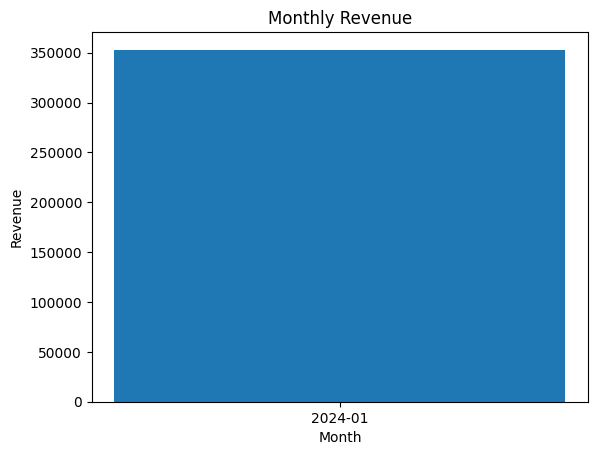

In [14]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(monthly_revenue["month"].astype(str), monthly_revenue["revenue"])

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue")
plt.show()

chart_file = "reports/monthly_revenue_chart.png"
plt.savefig(chart_file)
plt.close()

In [15]:
#Adding the chart to the PDF report

from fpdf import FPDF

pdf = FPDF()
pdf.add_page()

pdf.set_font("Arial", size=12)

pdf.cell(200,10,"Sales Report", ln=True, align="C")
pdf.ln(5)

pdf.cell(200,10,"Product Summary", ln=True)

for i in range(len(summary)):
    row = summary.iloc[i]
    text = f"{row['product']} | Units:{row['Total_Units']} | Revenue:{row['Total_Revenue']}"
    pdf.cell(200,8,text,ln=True)

pdf.ln(10)
pdf.cell(200,10,"Monthly Revenue Chart", ln=True)

pdf.image(chart_file, x=10, w=180)

pdf_file = "reports/sales_report.pdf"
pdf.output(pdf_file)

''

Q) Explain how you would secure the email credentials when deploying this pipeline in production.

Ans:

When deploying the pipeline in a production environment, email credentials should never be stored directly in the source code. Instead, several security practices should be followed.

- Environment Variables

     Credentials such as email addresses and passwords should be stored as environment variables. The Python script retrieves them using the os.getenv() function. This prevents sensitive information from being exposed in the code.

Example:

In [16]:
EMAIL_ADDRESS = os.getenv("EMAIL_ADDRESS")
EMAIL_PASSWORD = os.getenv("EMAIL_PASSWORD")

- Use of App Passwords

    Instead of using the primary email account password, a dedicated app password should be generated. This limits access and reduces security risks if the credentials are compromised.

- Secret Management Systems

    In production environments, credentials can also be stored in secure secret management services such as:

     - AWS Secrets Manager

     - Azure Key Vault

     - HashiCorp Vault

    These systems allow applications to securely retrieve credentials without storing them in code or configuration files.

- Access Control

    Permissions should be restricted so that only authorized services or users can access the credentials.